In [1]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

df1 = pd.read_excel('part1.xlsx')
df2 = pd.read_excel('part2.xlsx')

df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)
df.head()

(367437, 24)


,restaurant_id,original_name,original_address,matched_name,google_id,matched_address,latitude,longitude,day,hour,...,weekday,demand_month,taxi_zone_id,taxi_zone_name,estimated_area_sqft,capacity,turnover_rate,takeaway_ratio,eat_in_ratio,dropoff_count
0,50142786,DA ANDREA RISTORANTE,"160 8 AVENUE, MANHATTAN, NY 10011",Da Andrea Chelsea,0x89c2593ba314c0d1:0xd5579301e987a1bd,NaN,40.742092,-74.000594,7,6,...,6,6,90,Flatiron,2143.2,117.876,1.0,0.1,0.9,31.0
1,50142786,DA ANDREA RISTORANTE,"160 8 AVENUE, MANHATTAN, NY 10011",Da Andrea Chelsea,0x89c2593ba314c0d1:0xd5579301e987a1bd,NaN,40.742092,-74.000594,7,7,...,6,6,90,Flatiron,2143.2,117.876,1.0,0.1,0.9,47.0
2,50142786,DA ANDREA RISTORANTE,"160 8 AVENUE, MANHATTAN, NY 10011",Da Andrea Chelsea,0x89c2593ba314c0d1:0xd5579301e987a1bd,NaN,40.742092,-74.000594,7,8,...,6,6,90,Flatiron,2143.2,117.876,1.0,0.1,0.9,124.0
3,50142786,DA ANDREA RISTORANTE,"160 8 AVENUE, MANHATTAN, NY 10011",Da Andrea Chelsea,0x89c2593ba314c0d1:0xd5579301e987a1bd,NaN,40.742092,-74.000594,7,9,...,6,6,90,Flatiron,2143.2,117.876,1.0,0.1,0.9,200.0
4,50142786,DA ANDREA RISTORANTE,"160 8 AVENUE, MANHATTAN, NY 10011",Da Andrea Chelsea,0x89c2593ba314c0d1:0xd5579301e987a1bd,NaN,40.742092,-74.000594,7,10,...,6,6,90,Flatiron,2143.2,117.876,1.0,0.1,0.9,249.0


In [2]:
import re
import numpy as np
import pandas as pd

def parse_typical_time(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower().strip()

    # uniform sign
    x = x.replace("–", "-").replace("—", "-")

    pattern = r"""
        (?:
            spend\s+
        )?
        (\d+(?:\.\d+)?)                      # find the first figure
        \s*
        (min|mins|minute|minutes|hr|hrs|hour|hours)?   # first unit can be empty
        \s*
        (?:
            -|to
        )?
        \s*
        (?:
            (\d+(?:\.\d+)?)                  # second fighre
            \s*
            (min|mins|minute|minutes|hr|hrs|hour|hours)? # second unit
        )?
    """

    match = re.search(pattern, x, re.VERBOSE)

    if not match:
        return np.nan

    v1 = float(match.group(1))
    u1 = match.group(2)

    v2 = match.group(3)
    u2 = match.group(4)

    def normalize_unit(unit):
        if unit in ["hr", "hrs", "hour", "hours"]:
            return "hour"
        elif unit in ["min", "mins", "minute", "minutes"]:
            return "minute"
        return None

    u1 = normalize_unit(u1)
    u2 = normalize_unit(u2)

    # if one unit missing, assume two units are the same
    if v2 is not None:
        if u2 is None and u1 is not None:
            u2 = u1
        elif u1 is None and u2 is not None:
            u1 = u2

    if u1 is None:
        return np.nan

    def to_minutes(value, unit):
        if unit == "hour":
            return value * 60
        elif unit == "minute":
            return value
        return np.nan

    t1 = to_minutes(v1, u1)

    if v2 is not None:
        t2 = to_minutes(float(v2), u2)
        return (t1 + t2) / 2

    return t1


df["typical_time_mid"] = df["typical_time_spent"].apply(parse_typical_time)

# Fill missing typical visit time with the dataset median.
# The median is more robust than the mean when visit durations are right-skewed.
typical_time_median = df["typical_time_mid"].median()
df["typical_time_mid"] = df["typical_time_mid"].fillna(typical_time_median)

print(f"Median used for typical_time_mid: {typical_time_median:.2f} minutes")
print(f"Remaining missing values: {df['typical_time_mid'].isna().sum():,}")


Median used for typical_time_mid: 90.00 minutes
Remaining missing values: 0


In [3]:
df[["typical_time_spent","typical_time_mid"]].head(20)

,typical_time_spent,typical_time_mid
0,People typically spend 1.5-4 hours here,165.0
1,People typically spend 1.5-4 hours here,165.0
2,People typically spend 1.5-4 hours here,165.0
3,People typically spend 1.5-4 hours here,165.0
4,People typically spend 1.5-4 hours here,165.0
5,People typically spend 1.5-4 hours here,165.0
6,People typically spend 1.5-4 hours here,165.0
7,People typically spend 1.5-4 hours here,165.0
8,People typically spend 1.5-4 hours here,165.0
9,People typically spend 1.5-4 hours here,165.0


In [4]:
df["popularity"] = (
    df["rating"]
    * np.log1p(df["reviews"])
)

In [5]:
df["hour_sin"] = np.sin(
    2*np.pi*df["hour"]/24
)

df["hour_cos"] = np.cos(
    2*np.pi*df["hour"]/24
)

In [6]:
df["friday"] = (df["day"]==5).astype(int)

df["saturday"] = (df["day"]==6).astype(int)

df["sunday"] = (df["day"]==7).astype(int)

In [7]:
df["ln_area"] = np.log(df["estimated_area_sqft"])

In [8]:
df["ln_dropoff"] = np.log1p(df["dropoff_count"])

In [9]:
df["ln_reviews"] = np.log1p(df["reviews"])

In [10]:
# classification for busyness_score: three ordinal levels

# Boundaries:
# 0          -> No Wait
# (0, 50]    -> Queue Required
# above 50   -> Severe Queue

bins = [-0.001, 0, 50, np.inf]

level_labels = [0, 1, 2]

text_labels = [
    "No Wait",
    "Queue Required",
    "Severe Queue"
]

df["busyness_level"] = pd.cut(
    df["busyness_score"].clip(lower=0),
    bins=bins,
    labels=level_labels,
    include_lowest=True,
    right=True
).astype("Int64")

df["busyness_label"] = pd.cut(
    df["busyness_score"].clip(lower=0),
    bins=bins,
    labels=text_labels,
    include_lowest=True,
    right=True
).astype("string").fillna("Unknown")

# Check whether the three classes are reasonably represented.
class_distribution = pd.DataFrame({
    "count": df["busyness_level"].value_counts().sort_index(),
    "proportion": df["busyness_level"].value_counts(normalize=True).sort_index()
})

class_distribution.index = [
    f"{int(level)} - {text_labels[int(level)]}"
    for level in class_distribution.index
]

display(class_distribution)


,count,proportion
0 - No Wait,121495,0.330655
1 - Queue Required,121570,0.330859
2 - Severe Queue,124372,0.338485


In [11]:
import pandas as pd

# ============================================
# 1. Define variables by observation level
# ============================================

# Hour-level variables:
# each restaurant can have multiple observations across different times
hourly_variables = [
    "busyness_score",
    "dropoff_count"
]

# Restaurant-level variables:
# values are constant within each restaurant_id
restaurant_variables = [
    "typical_time_mid",
    "rating",
    "reviews",
    "estimated_area_sqft",
    "capacity",
    "turnover_rate",
    "takeaway_ratio",
    "eat_in_ratio",
    "dropoff_count"
]


# ============================================
# 2. Prepare datasets
# ============================================

hourly_df = df[hourly_variables].copy()

restaurant_df = (
    df.groupby("restaurant_id", as_index=False)[restaurant_variables]
      .first()
)


# ============================================
# 3. Function for descriptive statistics
# ============================================

def calculate_descriptive_statistics(data, variables):
    results = {}

    for col in variables:
        # Convert to numeric in case the column contains strings
        full_series = pd.to_numeric(data[col], errors="coerce")
        valid_series = full_series.dropna()

        results[col] = {
            "N": valid_series.count(),
            "Missing": full_series.isna().sum(),
            "Mean": valid_series.mean(),
            "Std": valid_series.std(),
            "Min": valid_series.min(),
            "25%": valid_series.quantile(0.25),
            "50%": valid_series.quantile(0.50),
            "75%": valid_series.quantile(0.75),
            "Max": valid_series.max(),
            "Skewness": valid_series.skew(),
            "Kurtosis": valid_series.kurt()
        }

    return pd.DataFrame(results).T


# ============================================
# 4. Calculate statistics separately
# ============================================

hourly_summary = calculate_descriptive_statistics(
    hourly_df,
    hourly_variables
)

restaurant_summary = calculate_descriptive_statistics(
    restaurant_df,
    restaurant_variables
)


# ============================================
# 5. Combine into one table
# ============================================

summary = pd.concat([
    hourly_summary,
    restaurant_summary
])

# Keep N and Missing as integers
summary["N"] = summary["N"].astype(int)
summary["Missing"] = summary["Missing"].astype(int)

# Round continuous statistics
numeric_stat_columns = [
    "Mean",
    "Std",
    "Min",
    "25%",
    "50%",
    "75%",
    "Max",
    "Skewness",
    "Kurtosis"
]

summary[numeric_stat_columns] = (
    summary[numeric_stat_columns].round(3)
)

summary.index.name = "Variable"

display(summary)

,N,Missing,Mean,Std,Min,25%,50%,75%,Max,Skewness,Kurtosis
Variable,,,,,,,,,,,
busyness_score,367437,0,34.777,29.699,0.00,0.000,37.00,58.000,100.00,0.203,-1.170
dropoff_count,367435,2,527.305,423.824,1.00,184.000,428.00,794.000,2574.00,1.130,1.332
typical_time_mid,2815,0,93.081,38.608,10.00,82.500,90.00,105.000,240.00,0.634,1.482
rating,2814,1,4.316,0.401,1.40,4.100,4.40,4.600,5.00,-1.367,3.512
reviews,2814,1,1021.335,2287.693,2.00,213.250,495.00,1080.000,59998.00,13.594,282.889
estimated_area_sqft,2815,0,1934.174,1973.084,200.00,657.808,1197.45,2287.750,8000.00,1.846,2.710
capacity,2815,0,128.493,137.070,10.00,41.191,76.50,152.825,664.00,2.065,4.105
turnover_rate,2815,0,1.682,0.792,0.80,1.100,1.20,2.500,3.00,0.786,-1.057
takeaway_ratio,2815,0,0.357,0.240,0.05,0.200,0.20,0.600,0.80,0.593,-1.177


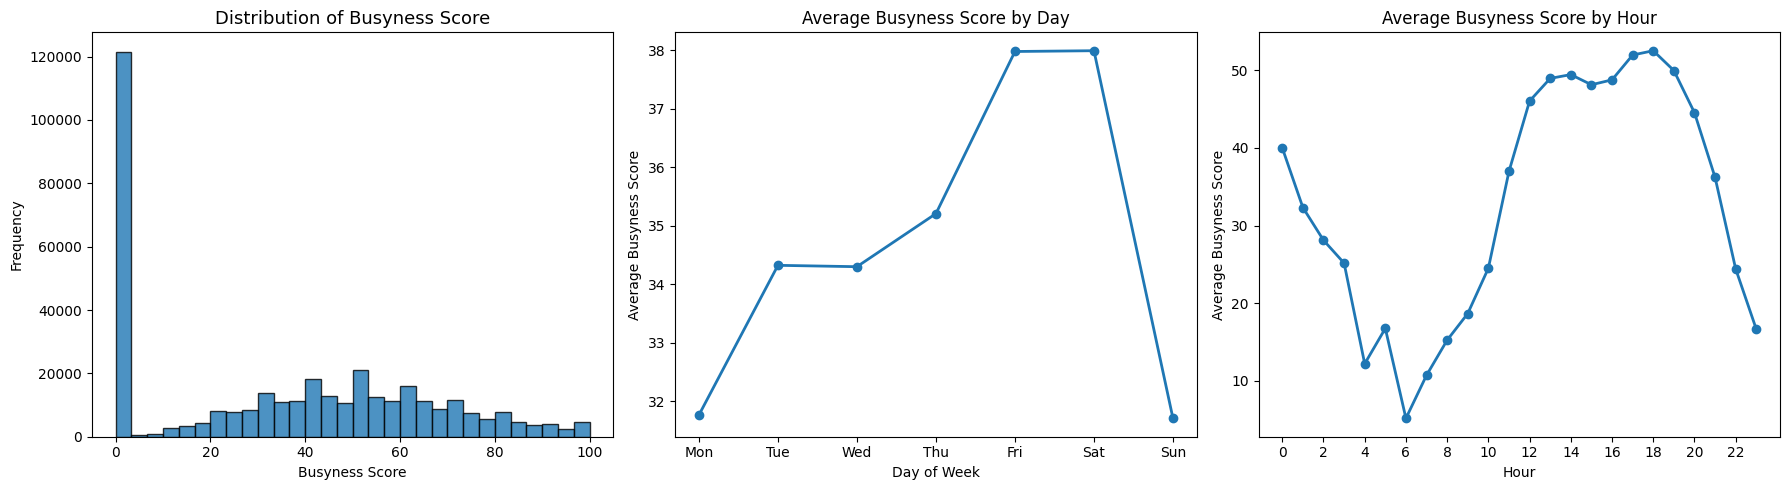

In [12]:
import matplotlib.pyplot as plt

# ============================================
# Descriptive Statistics
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -----------------------------
# 1. Histogram of busyness_score
# -----------------------------
axes[0].hist(
    df["busyness_score"],
    bins=30,
    edgecolor="black",
    alpha=0.8
)
axes[0].set_title("Distribution of Busyness Score", fontsize=13)
axes[0].set_xlabel("Busyness Score")
axes[0].set_ylabel("Frequency")


# -----------------------------
# 2. Average busyness_score by day
# -----------------------------
day_avg = (
    df.groupby("day")["busyness_score"]
      .mean()
      .sort_index()
)

axes[1].plot(
    day_avg.index,
    day_avg.values,
    marker="o",
    linewidth=2
)

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(day_labels)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Average Busyness Score")
axes[1].set_title("Average Busyness Score by Day")


# -----------------------------
# 3. Average busyness_score by hour
# -----------------------------
hour_avg = (
    df.groupby("hour")["busyness_score"]
      .mean()
      .sort_index()
)

axes[2].plot(
    hour_avg.index,
    hour_avg.values,
    marker="o",
    linewidth=2
)

axes[2].set_xticks(range(0, 24, 2))
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Average Busyness Score")
axes[2].set_title("Average Busyness Score by Hour")


plt.tight_layout()
plt.show()

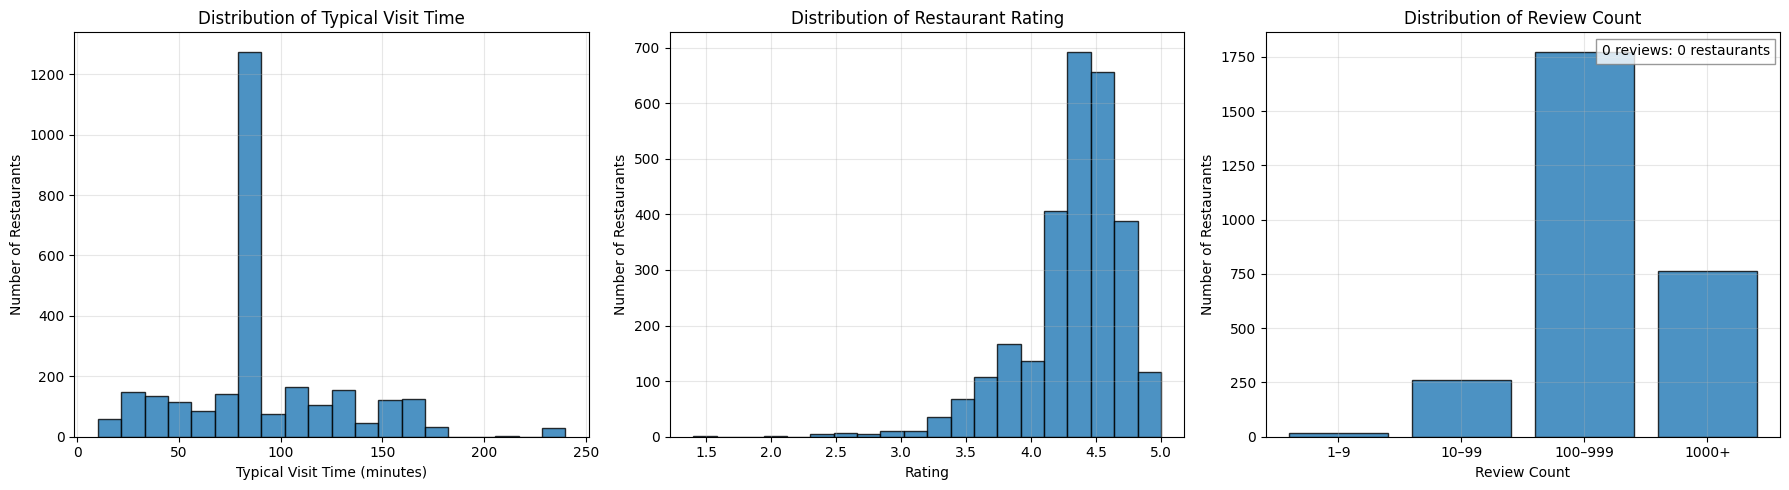

In [13]:
# ============================================
# Restaurant-level Features Distribution
# ============================================

restaurant_df = (
    df.groupby("restaurant_id", as_index=False)[
        ["typical_time_mid", "rating", "reviews"]
    ].first()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -----------------------------
# Typical visit time
# -----------------------------
axes[0].hist(
    restaurant_df["typical_time_mid"].dropna(),
    bins=20,
    edgecolor="black",
    alpha=0.8
)
axes[0].set_title("Distribution of Typical Visit Time")
axes[0].set_xlabel("Typical Visit Time (minutes)")
axes[0].set_ylabel("Number of Restaurants")

# -----------------------------
# Rating
# -----------------------------
axes[1].hist(
    restaurant_df["rating"].dropna(),
    bins=20,
    edgecolor="black",
    alpha=0.8
)
axes[1].set_title("Distribution of Restaurant Rating")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Number of Restaurants")

# -----------------------------
# Review Count
# -----------------------------
review_all = restaurant_df["reviews"].dropna()

zero_count = (review_all == 0).sum()

review = review_all[review_all > 0]

review_group = pd.cut(
    review,
    bins=[0, 10, 100, 1000, float("inf")],
    labels=["1–9", "10–99", "100–999", "1000+"],
    right=False
)

review_counts = review_group.value_counts().sort_index()

axes[2].bar(
    review_counts.index.astype(str),
    review_counts.values,
    edgecolor="black",
    alpha=0.8
)

axes[2].set_title("Distribution of Review Count")
axes[2].set_xlabel("Review Count")
axes[2].set_ylabel("Number of Restaurants")
axes[2].grid(axis="y", alpha=0.3)

# Add annotation
axes[2].text(
    0.98, 0.97,
    f"0 reviews: {zero_count:,} restaurants",
    transform=axes[2].transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

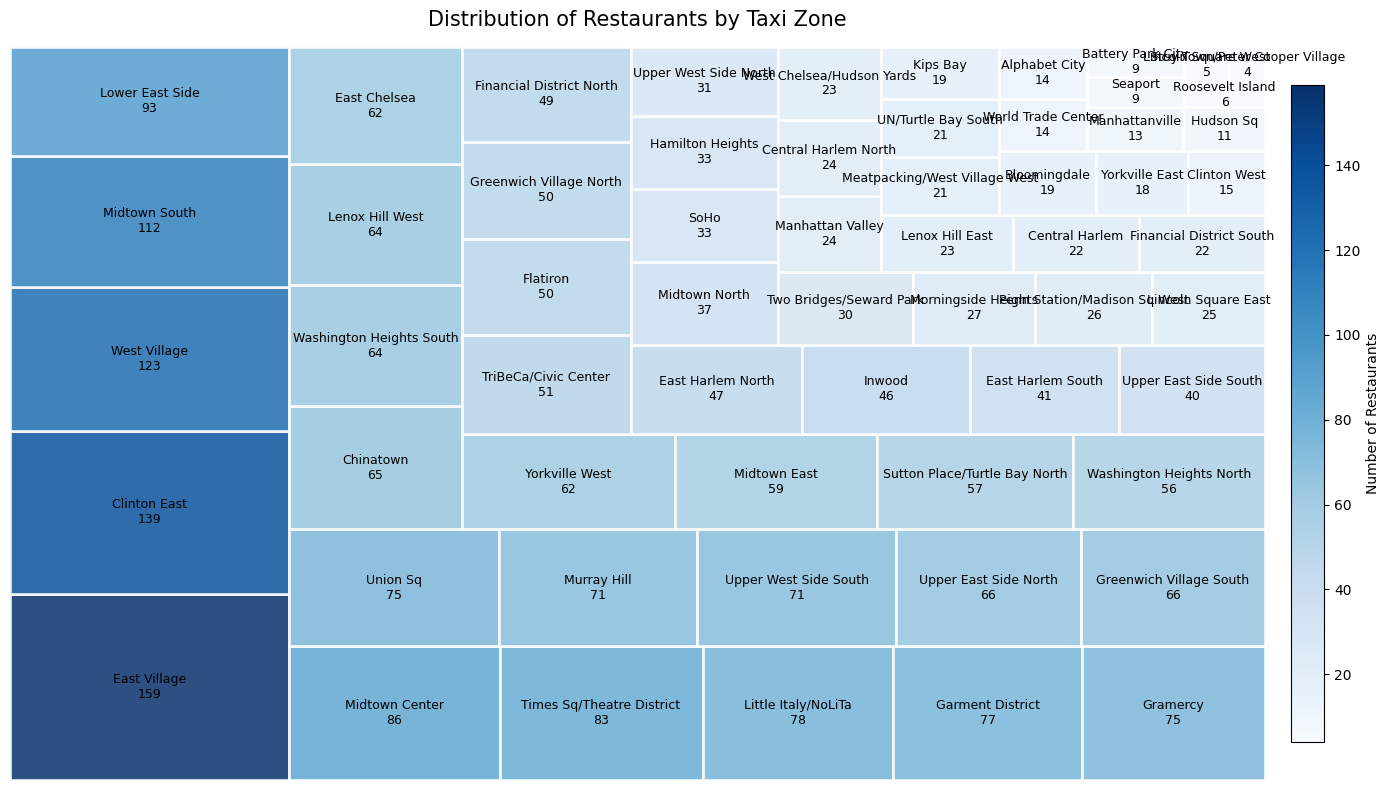

In [14]:
!pip install squarify
import matplotlib.colors as mcolors
import squarify

# ============================================
# Restaurant count by taxi zone
# ============================================

# each restaurant only keeps one record
restaurant_zone_df = (
    df.groupby("restaurant_id", as_index=False)["taxi_zone_name"]
      .first()
      .dropna(subset=["taxi_zone_name"])
)

# calculate the unique restaurant_id in each taxi zone
zone_counts = (
    restaurant_zone_df.groupby("taxi_zone_name")
                      .size()
                      .reset_index(name="restaurant_count")
                      .sort_values("restaurant_count", ascending=False)
)

# lables
labels = [
    f"{zone}\n{count:,}"
    for zone, count in zip(
        zone_counts["taxi_zone_name"],
        zone_counts["restaurant_count"]
    )
]

# depth = count of unique restaurant_id
norm = mcolors.Normalize(
    vmin=zone_counts["restaurant_count"].min(),
    vmax=zone_counts["restaurant_count"].max()
)

cmap = plt.cm.Blues

colors = [
    cmap(norm(count))
    for count in zone_counts["restaurant_count"]
]

# ============================================
# Draw treemap
# ============================================

fig, ax = plt.subplots(figsize=(14, 8))

squarify.plot(
    sizes=zone_counts["restaurant_count"],
    label=labels,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=2,
    ax=ax,
    text_kwargs={"fontsize": 9}
)

ax.set_title(
    "Distribution of Restaurants by Taxi Zone",
    fontsize=15,
    pad=15
)

ax.axis("off")

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Number of Restaurants")

plt.tight_layout()
plt.show()

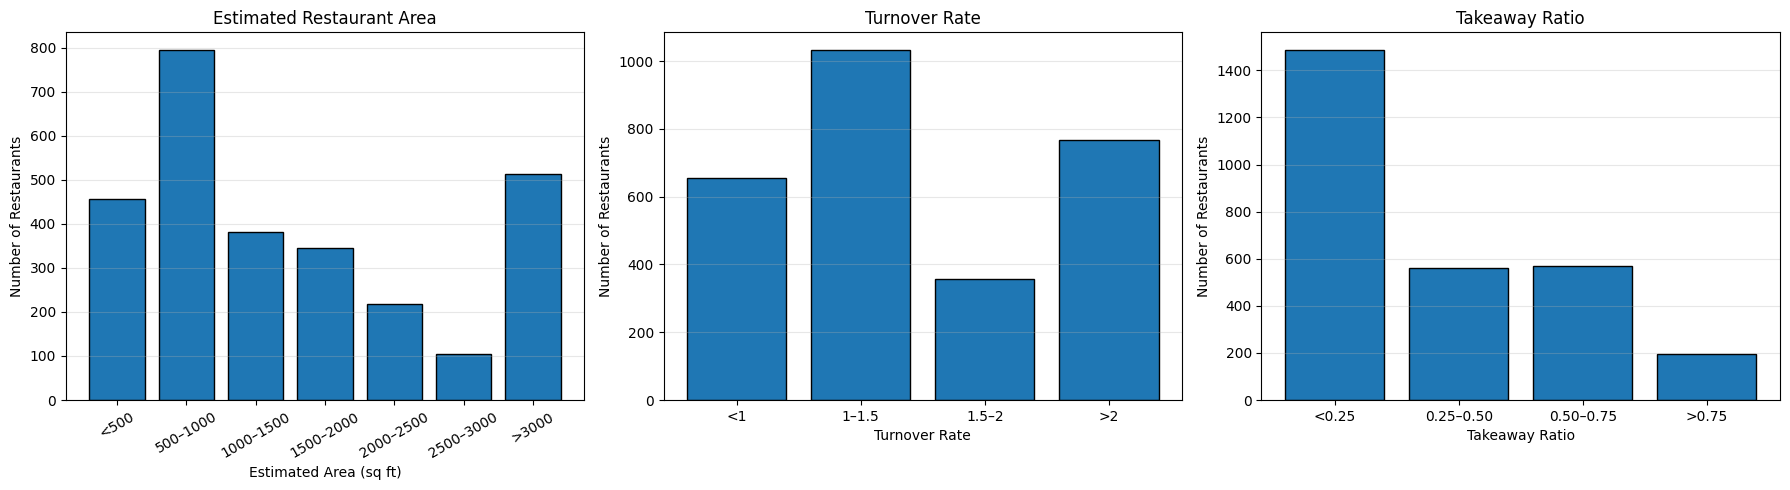

In [15]:
# ============================================
# Restaurant-level data
# ============================================

restaurant_df = (
    df.groupby("restaurant_id", as_index=False)[
        [
            "estimated_area_sqft",
            "turnover_rate",
            "takeaway_ratio"
        ]
    ].first()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================
# Estimated Area
# ============================================

area_group = pd.cut(
    restaurant_df["estimated_area_sqft"],
    bins=[0, 500, 1000, 1500, 2000, 2500, 3000, float("inf")],
    labels=[
        "<500",
        "500–1000",
        "1000–1500",
        "1500–2000",
        "2000–2500",
        "2500–3000",
        ">3000"
    ],
    include_lowest=True
)

area_count = area_group.value_counts().sort_index()

axes[0].bar(
    area_count.index.astype(str),
    area_count.values,
    edgecolor="black"
)
axes[0].set_title("Estimated Restaurant Area")
axes[0].set_xlabel("Estimated Area (sq ft)")
axes[0].set_ylabel("Number of Restaurants")
axes[0].tick_params(axis='x', rotation=30)

# ============================================
# Turnover Rate
# ============================================

turnover_group = pd.cut(
    restaurant_df["turnover_rate"],
    bins=[0, 1, 1.5, 2, float("inf")],
    labels=[
        "<1",
        "1–1.5",
        "1.5–2",
        ">2"
    ],
    include_lowest=True
)

turnover_count = turnover_group.value_counts().sort_index()

axes[1].bar(
    turnover_count.index.astype(str),
    turnover_count.values,
    edgecolor="black"
)

axes[1].set_title("Turnover Rate")
axes[1].set_xlabel("Turnover Rate")
axes[1].set_ylabel("Number of Restaurants")

# ============================================
# Takeaway Ratio
# ============================================

takeaway_group = pd.cut(
    restaurant_df["takeaway_ratio"],
    bins=[0, 0.25, 0.5, 0.75, 1],
    labels=[
        "<0.25",
        "0.25–0.50",
        "0.50–0.75",
        ">0.75"
    ],
    include_lowest=True
)

takeaway_count = takeaway_group.value_counts().sort_index()

axes[2].bar(
    takeaway_count.index.astype(str),
    takeaway_count.values,
    edgecolor="black"
)

axes[2].set_title("Takeaway Ratio")
axes[2].set_xlabel("Takeaway Ratio")
axes[2].set_ylabel("Number of Restaurants")

# ============================================
# Beautify
# ============================================

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

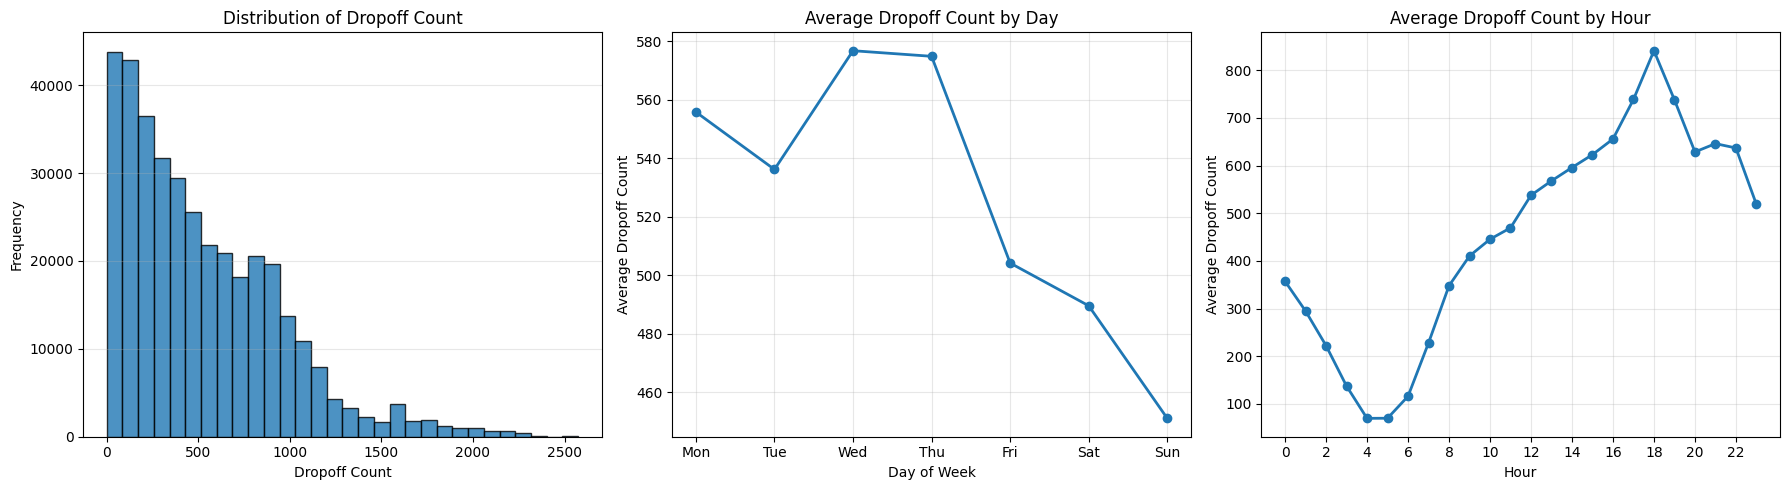

In [16]:
# ============================================
# Dropoff Count: Distribution, by Day, by Hour
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -----------------------------
# 1. Overall distribution
# -----------------------------
axes[0].hist(
    df["dropoff_count"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Distribution of Dropoff Count")
axes[0].set_xlabel("Dropoff Count")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", alpha=0.3)


# -----------------------------
# 2. Average dropoff count by day
# -----------------------------
dropoff_by_day = (
    df.groupby("day")["dropoff_count"]
      .mean()
      .sort_index()
)

axes[1].plot(
    dropoff_by_day.index,
    dropoff_by_day.values,
    marker="o",
    linewidth=2
)

axes[1].set_title("Average Dropoff Count by Day")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Average Dropoff Count")
axes[1].grid(alpha=0.3)

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(day_labels)


# -----------------------------
# 3. Average dropoff count by hour
# -----------------------------
dropoff_by_hour = (
    df.groupby("hour")["dropoff_count"]
      .mean()
      .sort_index()
)

axes[2].plot(
    dropoff_by_hour.index,
    dropoff_by_hour.values,
    marker="o",
    linewidth=2
)

axes[2].set_title("Average Dropoff Count by Hour")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Average Dropoff Count")
axes[2].set_xticks(range(0, 24, 2))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
restaurant_ids = df["restaurant_id"].unique()

print(len(restaurant_ids))

2815


In [18]:
train_restaurants = restaurant_ids[:2000]

test_restaurants = restaurant_ids[2000:]

In [19]:
train_df = df[df["restaurant_id"].isin(train_restaurants)].copy()

test_df = df[df["restaurant_id"].isin(test_restaurants)].copy()

print(train_df.shape)
print(test_df.shape)

(261500, 36)
(105937, 36)


In [20]:
train_zones = set(train_df["taxi_zone_id"].unique())
test_zones = set(test_df["taxi_zone_id"].unique())

missing_zones = test_zones - train_zones

print(f"Train taxi zones: {len(train_zones)}")
print(f"Test taxi zones : {len(test_zones)}")
print(f"Missing zones in train: {len(missing_zones)}")

if len(missing_zones) == 0:
    print("✓ All taxi zones in the test set are present in the training set.")
else:
    print("✗ Missing taxi zones:")
    print(sorted(missing_zones))

Train taxi zones: 60
Test taxi zones : 60
Missing zones in train: 0
✓ All taxi zones in the test set are present in the training set.


In [21]:
import statsmodels.api as sm

# ============================================
# 1. Numerical and categorical variables
# ============================================

feature_cols = [
    "hour_sin",
    "hour_cos",
    "friday",
    "saturday",
    "sunday",
    "typical_time_mid",
    "rating",
    "ln_reviews",
    "ln_area",
    "takeaway_ratio",
    "ln_dropoff"
]

categorical_cols = [
    "taxi_zone_id"
]

target_col = "busyness_score"

train_model_df = train_df[
    feature_cols + categorical_cols + [target_col]
].replace([np.inf, -np.inf], np.nan).dropna()

test_model_df = test_df[
    feature_cols + categorical_cols + [target_col]
].replace([np.inf, -np.inf], np.nan).dropna()

In [22]:
# ============================================
# 2. Construct train and test datasets
# ============================================

X_train = train_model_df[
    feature_cols + categorical_cols
].copy()

X_test = test_model_df[
    feature_cols + categorical_cols
].copy()

y_train = train_model_df[target_col].copy()
y_test = test_model_df[target_col].copy()

# Treat taxi_zone as a categorical variable
X_train["taxi_zone_id"] = X_train["taxi_zone_id"].astype(str)
X_test["taxi_zone_id"] = X_test["taxi_zone_id"].astype(str)

# ============================================
# 3. Check taxi-zone coverage
# ============================================

train_zones = set(X_train["taxi_zone_id"].dropna())
test_zones = set(X_test["taxi_zone_id"].dropna())

unseen_test_zones = test_zones - train_zones

print("Number of train zones:", len(train_zones))
print("Number of test zones:", len(test_zones))
print("Zones present in test but absent from train:", unseen_test_zones)

# ============================================
# 4. One-hot encode taxi-zone fixed effects
# ============================================

X_train = pd.get_dummies(
    X_train,
    columns=["taxi_zone_id"],
    prefix="taxi_zone_id",
    drop_first=True,
    dtype=float
)

X_test = pd.get_dummies(
    X_test,
    columns=["taxi_zone_id"],
    prefix="taxi_zone_id",
    drop_first=True,
    dtype=float
)

# Force test columns to match train columns
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Convert all explanatory variables to numeric
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

# ============================================
# 5. Handle missing or infinite values
# ============================================

train_valid = (
    X_train.notna().all(axis=1)
    & y_train.notna()
)

test_valid = (
    X_test.notna().all(axis=1)
    & y_test.notna()
)

X_train = X_train.loc[train_valid]
y_train = y_train.loc[train_valid]

X_test = X_test.loc[test_valid]
y_test = y_test.loc[test_valid]

# ============================================
# 6. Add intercept
# ============================================

X_train = sm.add_constant(
    X_train,
    has_constant="add"
)

X_test = sm.add_constant(
    X_test,
    has_constant="add"
)

# Ensure identical ordering
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# ============================================
# 7. Fit OLS
# ============================================

model = sm.OLS(
    y_train.astype(float),
    X_train.astype(float)
)

results = model.fit()

print(results.summary())

Number of train zones: 60
Number of test zones: 60
Zones present in test but absent from train: set()
                            OLS Regression Results                            
Dep. Variable:         busyness_score   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     1454.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:59:22   Log-Likelihood:            -1.2147e+06
No. Observations:              261500   AIC:                         2.430e+06
Df Residuals:                  261429   BIC:                         2.430e+06
Df Model:                          70                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

train_pred = results.predict(X_train)
test_pred = results.predict(X_test)

print("Train")
print("R2 =", r2_score(y_train, train_pred))
print("MAE =", mean_absolute_error(y_train, train_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_train, train_pred)))

print()

print("Test")
print("R2 =", r2_score(y_test, test_pred))
print("MAE =", mean_absolute_error(y_test, test_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, test_pred)))

Train
R2 = 0.28017605283417946
MAE = 20.510999354292952
RMSE = 25.184591926457003

Test
R2 = 0.2661651314952669
MAE = 20.749421539337646
RMSE = 25.472843250837336


In [24]:
features = [
    "hour_sin",
    "hour_cos",
    "friday",
    "saturday",
    "sunday",
    "typical_time_mid",
    "rating",
    "ln_reviews",
    "ln_dropoff",
    "ln_area",
    "takeaway_ratio"
]

categories = [
    "taxi_zone_id"
]

In [25]:
X_train = train_model_df[features+categories]
y_train = train_model_df["busyness_score"]

X_test = test_model_df[features+categories]
y_test = test_model_df["busyness_score"]

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

print("Train")
print("R2 =", r2_score(y_train, train_pred))
print("MAE =", mean_absolute_error(y_train, train_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_train, train_pred)))

print()

print("Test")
print("R2 =", r2_score(y_test, test_pred))
print("MAE =", mean_absolute_error(y_test, test_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, test_pred)))

Train
R2 = 0.5938218504125885
MAE = 14.13100453292503
RMSE = 18.918210403710024

Test
R2 = 0.42431543822350526
MAE = 17.13989589262731
RMSE = 22.561633644079123


In [27]:
importance = (
    pd.Series(
        rf.feature_importances_,
        index=features + categories
    )
    .sort_values(ascending=False)
)

print(importance)

hour_sin            0.368882
hour_cos            0.184289
takeaway_ratio      0.164437
ln_reviews          0.058953
typical_time_mid    0.057352
ln_area             0.045087
rating              0.041878
ln_dropoff          0.032501
taxi_zone_id        0.031018
saturday            0.007379
friday              0.005526
sunday              0.002699
dtype: float64


In [28]:
pip install xgboost

In [29]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

train_pred = xgb.predict(X_train)
test_pred = xgb.predict(X_test)

In [30]:
print("Train")
print("R2 =", r2_score(y_train, train_pred))
print("MAE =", mean_absolute_error(y_train, train_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_train, train_pred)))

print()

print("Test")
print("R2 =", r2_score(y_test, test_pred))
print("MAE =", mean_absolute_error(y_test, test_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, test_pred)))

Train
R2 = 0.6166555285453796
MAE = 13.981596946716309
RMSE = 18.37876801555347

Test
R2 = 0.453041672706604
MAE = 16.899154663085938
RMSE = 21.99152627225321


In [31]:
importance = (
    pd.Series(
        xgb.feature_importances_,
        index=features + categories
    )
    .sort_values(ascending=False)
)

print(importance)

hour_sin            0.334931
takeaway_ratio      0.149502
hour_cos            0.138437
friday              0.065200
typical_time_mid    0.058109
saturday            0.048254
ln_dropoff          0.044019
rating              0.039502
ln_reviews          0.036760
taxi_zone_id        0.033856
ln_area             0.031290
sunday              0.020139
dtype: float32


## Ordinal Classification Models

This section predicts the three-level ordinal target `busyness_level`:

0. No Wait
1. Queue Required
2. Severe Queue

Five classification models are compared:

1. Multinomial Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. XGBoost

The models are evaluated using Accuracy, Weighted F1-score, Quadratic Weighted Kappa (QWK), Mean Absolute Error (MAE), and two business-critical cross-level error rates:

- **C-end critical error:** actual Severe Queue (`2`) but predicted No Wait (`0`).
- **B-end critical error:** actual No Wait (`0`) but predicted Severe Queue (`2`).

Both the overall sample rate and the conditional rate within the relevant actual class are reported. A 3×3 confusion matrix is also produced for each model on the test set.


In [33]:
# ============================================
# 1. Prepare classification data
# ============================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

# Reuse the restaurant-level train/test split created above.
# The continuous busyness_score is intentionally excluded from X.
classification_target = "busyness_level"

classification_features = [
    "hour_sin",
    "hour_cos",
    "friday",
    "saturday",
    "sunday",
    "typical_time_mid",
    "rating",
    "ln_reviews",
    "ln_area",
    "takeaway_ratio",
    "ln_dropoff"
]

classification_categories = [
    "taxi_zone_id"
]

required_columns = (
    classification_features
    + classification_categories
    + [classification_target]
)

missing_train_columns = [
    col for col in required_columns if col not in train_df.columns
]
missing_test_columns = [
    col for col in required_columns if col not in test_df.columns
]

if missing_train_columns or missing_test_columns:
    raise KeyError(
        "Missing classification columns. "
        f"Train missing: {missing_train_columns}; "
        f"Test missing: {missing_test_columns}"
    )

classification_train_df = (
    train_df[required_columns]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[classification_target])
    .copy()
)

classification_test_df = (
    test_df[required_columns]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[classification_target])
    .copy()
)

X_train_cls = classification_train_df[
    classification_features + classification_categories
].copy()

X_test_cls = classification_test_df[
    classification_features + classification_categories
].copy()

y_train_cls = classification_train_df[classification_target].astype(int)
y_test_cls = classification_test_df[classification_target].astype(int)

# Keep taxi-zone IDs categorical, even when the original column is numeric.
for col in classification_categories:
    X_train_cls[col] = X_train_cls[col].astype("string")
    X_test_cls[col] = X_test_cls[col].astype("string")

# Verify that ordinal labels are encoded as consecutive integers.
observed_classes = np.sort(y_train_cls.unique())
expected_classes = np.arange(observed_classes.min(), observed_classes.max() + 1)

if not np.array_equal(observed_classes, expected_classes):
    raise ValueError(
        "Training labels must be consecutive integers for XGBoost. "
        f"Observed classes: {observed_classes.tolist()}"
    )

unseen_test_classes = sorted(set(y_test_cls.unique()) - set(observed_classes))
if unseen_test_classes:
    raise ValueError(
        "The test set contains classes absent from the training set: "
        f"{unseen_test_classes}"
    )

print("Classification training shape:", X_train_cls.shape)
print("Classification test shape:", X_test_cls.shape)
print("Training class distribution:")
print(y_train_cls.value_counts(normalize=True).sort_index().rename("proportion"))

# Balanced sample weights are used by XGBoost.
# Logistic Regression, Decision Tree and Random Forest use class_weight='balanced'.
xgb_train_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_train_cls
)


Classification training shape: (261500, 12)
Classification test shape: (105937, 12)
Training class distribution:
busyness_level
0    0.327480
1    0.331556
2    0.340964
Name: proportion, dtype: float64


In [34]:
# ============================================
# 2. Build preprocessing pipelines
# ============================================

# Scaling is important for Logistic Regression and especially KNN.
scaled_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Tree-based models do not require feature scaling.
tree_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", scaled_numeric_transformer, classification_features),
        ("categorical", categorical_transformer, classification_categories)
    ],
    remainder="drop"
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", tree_numeric_transformer, classification_features),
        ("categorical", categorical_transformer, classification_categories)
    ],
    remainder="drop"
)


In [35]:
# ============================================
# 3. Define and train five classification models
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

classification_models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", scaled_preprocessor),
            (
                "model",
                LogisticRegression(
                    solver="lbfgs",
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]
    ),

    "KNN": Pipeline(
        steps=[
            ("preprocessor", scaled_preprocessor),
            (
                "model",
                KNeighborsClassifier(
                    n_neighbors=15,
                    weights="distance",
                    metric="minkowski",
                    p=2,
                    n_jobs=-1
                )
            )
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=12,
                    min_samples_leaf=5,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=16,
                    min_samples_leaf=5,
                    class_weight="balanced_subsample",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    ),

    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                XGBClassifier(
                    objective="multi:softprob",
                    num_class=len(observed_classes),
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    min_child_weight=3,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_lambda=1.0,
                    eval_metric="mlogloss",
                    tree_method="hist",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )
}

for model_name, model in classification_models.items():
    print(f"Training {model_name}...")

    if model_name == "XGBoost":
        model.fit(
            X_train_cls,
            y_train_cls,
            model__sample_weight=xgb_train_sample_weight
        )
    else:
        model.fit(X_train_cls, y_train_cls)

print("All classification models have been trained.")


Training Logistic Regression...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
All classification models have been trained.


In [36]:
# ============================================
# 4. Evaluate ordinal classification performance
# ============================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    mean_absolute_error,
    confusion_matrix
)

import time
import numpy as np
import pandas as pd


def safe_rate(numerator, denominator):
    """Return a valid rate; use 0 when the denominator is zero."""
    return numerator / denominator if denominator > 0 else 0.0


def calculate_ordinal_metrics(
    model_name,
    y_true,
    y_pred,
    dataset_name,
    prediction_time
):
    """
    Calculate standard ordinal metrics and two business-critical
    cross-level error rates using already-generated predictions.

    Class definitions:
    0 = No Wait
    1 = Queue Required
    2 = Severe Queue

    Critical errors:
    - C-end: actual 2, predicted 0
    - B-end: actual 0, predicted 2
    """

    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    n_samples = len(y_true)

    # C-end critical error: model says No Wait, but reality is Severe Queue.
    c_end_error_count = np.sum((y_true == 2) & (y_pred == 0))
    actual_severe_count = np.sum(y_true == 2)

    # B-end critical error: model says Severe Queue, but reality is No Wait.
    b_end_error_count = np.sum((y_true == 0) & (y_pred == 2))
    actual_no_wait_count = np.sum(y_true == 0)

    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),

        "Weighted_F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "QWK": cohen_kappa_score(
            y_true,
            y_pred,
            labels=observed_classes,
            weights="quadratic"
        ),

        "MAE_levels": mean_absolute_error(y_true, y_pred),

        # Percentage of all observations.
        "C_end_critical_overall_rate": safe_rate(
            c_end_error_count,
            n_samples
        ),

        # Of all truly Severe Queue observations, percentage predicted No Wait.
        "C_end_critical_rate_given_actual_severe": safe_rate(
            c_end_error_count,
            actual_severe_count
        ),

        # Percentage of all observations.
        "B_end_critical_overall_rate": safe_rate(
            b_end_error_count,
            n_samples
        ),

        # Of all truly No Wait observations, percentage predicted Severe Queue.
        "B_end_critical_rate_given_actual_no_wait": safe_rate(
            b_end_error_count,
            actual_no_wait_count
        ),

        "Prediction_time_seconds": prediction_time
    }


ordinal_results = []
classification_predictions = {}


for model_name, model in classification_models.items():

    print(f"\nEvaluating {model_name}...")

    # -------------------------
    # Train predictions
    # -------------------------
    start_time = time.time()

    train_predictions = model.predict(
        X_train_cls
    ).astype(int)

    train_prediction_time = time.time() - start_time

    print(
        f"Train prediction completed: "
        f"{train_prediction_time:.2f} seconds"
    )

    # -------------------------
    # Test predictions
    # -------------------------
    start_time = time.time()

    test_predictions = model.predict(
        X_test_cls
    ).astype(int)

    test_prediction_time = time.time() - start_time

    print(
        f"Test prediction completed: "
        f"{test_prediction_time:.2f} seconds"
    )

    # Save predictions so later cells can reuse them.
    classification_predictions[model_name] = {
        "train": train_predictions,
        "test": test_predictions
    }

    ordinal_results.append(
        calculate_ordinal_metrics(
            model_name=model_name,
            y_true=y_train_cls,
            y_pred=train_predictions,
            dataset_name="Train",
            prediction_time=train_prediction_time
        )
    )

    ordinal_results.append(
        calculate_ordinal_metrics(
            model_name=model_name,
            y_true=y_test_cls,
            y_pred=test_predictions,
            dataset_name="Test",
            prediction_time=test_prediction_time
        )
    )


# ============================================
# Result table
# ============================================

ordinal_results_df = pd.DataFrame(ordinal_results)

metrics_to_round = [
    "Accuracy",
    "Weighted_F1",
    "QWK",
    "MAE_levels",
    "C_end_critical_overall_rate",
    "C_end_critical_rate_given_actual_severe",
    "B_end_critical_overall_rate",
    "B_end_critical_rate_given_actual_no_wait",
    "Prediction_time_seconds"
]

ordinal_results_df[metrics_to_round] = (
    ordinal_results_df[metrics_to_round].round(4)
)

print("\nOrdinal classification results:")

display(
    ordinal_results_df.sort_values(
        by=["Dataset", "QWK", "Weighted_F1", "Accuracy", "MAE_levels"],
        ascending=[True, False, False, False, True]
    ).reset_index(drop=True)
)


# ============================================
# Test-set model comparison
# ============================================

print("\nTest-set comparison:")

test_results_df = (
    ordinal_results_df[
        ordinal_results_df["Dataset"] == "Test"
    ]
    .drop(columns="Dataset")
    .sort_values(
        by=[
            "QWK",
            "Weighted_F1",
            "Accuracy",
            "MAE_levels"
        ],
        ascending=[
            False,
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

display(test_results_df)


best_model_name = test_results_df.loc[0, "Model"]
best_model = classification_models[best_model_name]

print(
    f"\nBest model by test QWK: "
    f"{best_model_name}"
)



Evaluating Logistic Regression...
Train prediction completed: 0.35 seconds
Test prediction completed: 0.15 seconds

Evaluating KNN...
Train prediction completed: 2934.60 seconds
Test prediction completed: 963.38 seconds

Evaluating Decision Tree...
Train prediction completed: 0.46 seconds
Test prediction completed: 0.16 seconds

Evaluating Random Forest...
Train prediction completed: 4.43 seconds
Test prediction completed: 1.82 seconds

Evaluating XGBoost...
Train prediction completed: 3.13 seconds
Test prediction completed: 1.24 seconds

Ordinal classification results:


,Model,Dataset,Accuracy,Weighted_F1,QWK,MAE_levels,C_end_critical_overall_rate,C_end_critical_rate_given_actual_severe,B_end_critical_overall_rate,B_end_critical_rate_given_actual_no_wait,Prediction_time_seconds
0,XGBoost,Test,0.6274,0.6242,0.5992,0.4330,0.0321,0.0966,0.0283,0.0835,1.2380
1,Random Forest,Test,0.6213,0.6154,0.5893,0.4452,0.0347,0.1045,0.0317,0.0938,1.8198
2,Decision Tree,Test,0.5996,0.5992,0.5606,0.4631,0.0361,0.1086,0.0266,0.0786,0.1610
3,KNN,Test,0.5656,0.5629,0.4960,0.5202,0.0437,0.1316,0.0421,0.1242,963.3789
4,Logistic Regression,Test,0.5284,0.5125,0.4610,0.5763,0.0509,0.1531,0.0538,0.1590,0.1507
5,KNN,Train,0.9984,0.9984,0.9988,0.0016,0.0000,0.0001,0.0000,0.0000,2934.6028
6,XGBoost,Train,0.7339,0.7318,0.7166,0.3065,0.0223,0.0654,0.0181,0.0552,3.1296
7,Random Forest,Train,0.7416,0.7388,0.7158,0.3034,0.0249,0.0730,0.0200,0.0611,4.4345
8,Decision Tree,Train,0.6812,0.6800,0.6750,0.3576,0.0239,0.0700,0.0149,0.0456,0.4640
9,Logistic Regression,Train,0.5458,0.5291,0.4850,0.5531,0.0511,0.1498,0.0479,0.1461,0.3491



Test-set comparison:


,Model,Accuracy,Weighted_F1,QWK,MAE_levels,C_end_critical_overall_rate,C_end_critical_rate_given_actual_severe,B_end_critical_overall_rate,B_end_critical_rate_given_actual_no_wait,Prediction_time_seconds
0,XGBoost,0.6274,0.6242,0.5992,0.4330,0.0321,0.0966,0.0283,0.0835,1.2380
1,Random Forest,0.6213,0.6154,0.5893,0.4452,0.0347,0.1045,0.0317,0.0938,1.8198
2,Decision Tree,0.5996,0.5992,0.5606,0.4631,0.0361,0.1086,0.0266,0.0786,0.1610
3,KNN,0.5656,0.5629,0.4960,0.5202,0.0437,0.1316,0.0421,0.1242,963.3789
4,Logistic Regression,0.5284,0.5125,0.4610,0.5763,0.0509,0.1531,0.0538,0.1590,0.1507



Best model by test QWK: XGBoost


## Test-set 3×3 Confusion Matrices

Rows represent the **actual class** and columns represent the **predicted class**.

- Cell `(actual 2, predicted 0)` is the C-end critical error.
- Cell `(actual 0, predicted 2)` is the B-end critical error.

The first table shows raw counts. The second table is normalized by actual class, so every row sums to 100%.


In [38]:
# ============================================
# 5. Test-set 3x3 confusion matrices
# ============================================

class_names = [
    "0 - No Wait",
    "1 - Queue Required",
    "2 - Severe Queue"
]

confusion_matrices = {}

for model_name in classification_models:
    y_pred_test = classification_predictions[model_name]["test"]

    cm_count = confusion_matrix(
        y_test_cls,
        y_pred_test,
        labels=[0, 1, 2]
    )

    # Normalize each row by its actual-class total.
    row_totals = cm_count.sum(axis=1, keepdims=True)
    cm_row_rate = np.divide(
        cm_count,
        row_totals,
        out=np.zeros_like(cm_count, dtype=float),
        where=row_totals != 0
    )

    cm_count_df = pd.DataFrame(
        cm_count,
        index=[f"Actual: {name}" for name in class_names],
        columns=[f"Predicted: {name}" for name in class_names]
    )

    cm_row_pct_df = pd.DataFrame(
        cm_row_rate * 100,
        index=[f"Actual: {name}" for name in class_names],
        columns=[f"Predicted: {name}" for name in class_names]
    ).round(2)

    confusion_matrices[model_name] = {
        "count": cm_count_df,
        "row_percentage": cm_row_pct_df
    }

    print(f"\n{model_name} - Confusion Matrix (count)")
    display(cm_count_df)

    print(
        f"{model_name} - Confusion Matrix "
        f"(% within each actual class)"
    )
    display(cm_row_pct_df)

    c_end_count = cm_count[2, 0]
    b_end_count = cm_count[0, 2]

    print(
        f"C-end critical errors (actual Severe Queue -> predicted No Wait): "
        f"{c_end_count}"
    )
    print(
        f"B-end critical errors (actual No Wait -> predicted Severe Queue): "
        f"{b_end_count}"
    )



Logistic Regression - Confusion Matrix (count)


,Predicted: 0 - No Wait,Predicted: 1 - Queue Required,Predicted: 2 - Severe Queue
Actual: 0 - No Wait,24670,5489,5700
Actual: 1 - Queue Required,10747,9300,14821
Actual: 2 - Severe Queue,5391,7812,22007


Logistic Regression - Confusion Matrix (% within each actual class)


,Predicted: 0 - No Wait,Predicted: 1 - Queue Required,Predicted: 2 - Severe Queue
Actual: 0 - No Wait,68.80,15.31,15.90
Actual: 1 - Queue Required,30.82,26.67,42.51
Actual: 2 - Severe Queue,15.31,22.19,62.50


C-end critical errors (actual Severe Queue -> predicted No Wait): 5391
B-end critical errors (actual No Wait -> predicted Severe Queue): 5700

KNN - Confusion Matrix (count)


...

C-end critical errors (actual Severe Queue -> predicted No Wait): 3680
B-end critical errors (actual No Wait -> predicted Severe Queue): 3363

XGBoost - Confusion Matrix (count)


,Predicted: 0 - No Wait,Predicted: 1 - Queue Required,Predicted: 2 - Severe Queue
Actual: 0 - No Wait,27631,5235,2993
Actual: 1 - Queue Required,5994,16235,12639
Actual: 2 - Severe Queue,3401,9214,22595


XGBoost - Confusion Matrix (% within each actual class)


,Predicted: 0 - No Wait,Predicted: 1 - Queue Required,Predicted: 2 - Severe Queue
Actual: 0 - No Wait,77.05,14.60,8.35
Actual: 1 - Queue Required,17.19,46.56,36.25
Actual: 2 - Severe Queue,9.66,26.17,64.17


C-end critical errors (actual Severe Queue -> predicted No Wait): 3401
B-end critical errors (actual No Wait -> predicted Severe Queue): 2993


Reviews row sums:
reviews_bin
(1.999, 176.0]       100.0
(176.0, 369.0]       100.0
(369.0, 658.0]       100.0
(658.0, 1325.0]      100.0
(1325.0, 59998.0]    100.0
dtype: float64

Rating row sums:
rating_bin
(1.395, 2.12]    100.0
(2.12, 2.84]     100.0
(2.84, 3.56]     100.0
(3.56, 4.28]     100.0
(4.28, 5.0]      100.0
dtype: float64

Typical time row sums:
typical_time_bin
(9.999, 67.5]     100.0
(67.5, 90.0]      100.0
(90.0, 120.0]     100.0
(120.0, 240.0]    100.0
dtype: float64


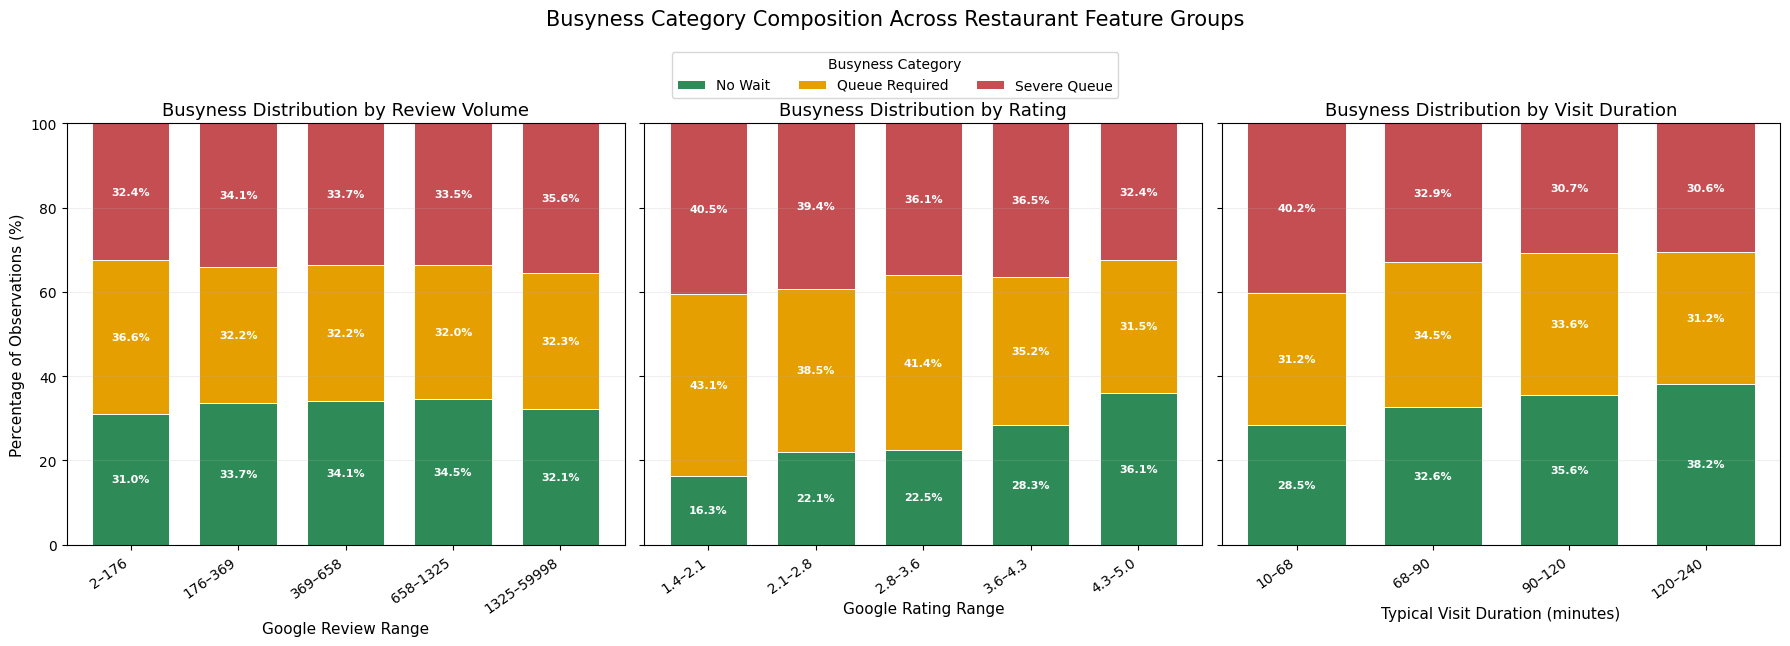

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Prepare data
# =========================================================
df_plot = df.copy()

busyness_order = [
    "No Wait",
    "Queue Required",
    "Severe Queue"
]

# 根据你的三分类标准划分 busyness_score
df_plot["busyness_category"] = pd.cut(
    df_plot["busyness_score"],
    bins=[-0.001, 0, 50, np.inf],
    labels=busyness_order,
    include_lowest=True,
    right=True
)


# =========================================================
# 2. Divide each feature into five groups
# =========================================================

# Reviews: use quintiles because reviews are extremely right-skewed
df_plot["reviews_bin"] = pd.qcut(
    df_plot["reviews"],
    q=5,
    duplicates="drop"
)

# Rating: use five equal-width intervals because rating has a fixed scale
df_plot["rating_bin"] = pd.cut(
    df_plot["rating"],
    bins=5,
    include_lowest=True
)

# Typical time: use quintiles for more balanced sample sizes
df_plot["typical_time_bin"] = pd.qcut(
    df_plot["typical_time_mid"],
    q=5,
    duplicates="drop"
)


# =========================================================
# 3. Calculate within-bin percentages
# =========================================================
def calculate_busyness_percentages(data, bin_column):
    """
    Calculate the percentage of each busyness category
    within every feature interval.

    Each row sums to 100%.
    """
    table = pd.crosstab(
        data[bin_column],
        data["busyness_category"],
        normalize="index"
    ) * 100

    # Ensure all three categories exist and keep a fixed order
    table = table.reindex(
        columns=busyness_order,
        fill_value=0
    )

    return table


reviews_pct = calculate_busyness_percentages(
    df_plot.dropna(subset=["reviews_bin", "busyness_category"]),
    "reviews_bin"
)

rating_pct = calculate_busyness_percentages(
    df_plot.dropna(subset=["rating_bin", "busyness_category"]),
    "rating_bin"
)

typical_time_pct = calculate_busyness_percentages(
    df_plot.dropna(subset=["typical_time_bin", "busyness_category"]),
    "typical_time_bin"
)


# Check that every row sums to 100%
print("Reviews row sums:")
print(reviews_pct.sum(axis=1).round(2))

print("\nRating row sums:")
print(rating_pct.sum(axis=1).round(2))

print("\nTypical time row sums:")
print(typical_time_pct.sum(axis=1).round(2))


# =========================================================
# 4. Format interval labels
# =========================================================
def format_interval_labels(index, decimals=1):
    labels = []

    for interval in index:
        if isinstance(interval, pd.Interval):
            labels.append(
                f"{interval.left:.{decimals}f}–"
                f"{interval.right:.{decimals}f}"
            )
        else:
            labels.append(str(interval))

    return labels


reviews_pct.index = format_interval_labels(
    reviews_pct.index,
    decimals=0
)

rating_pct.index = format_interval_labels(
    rating_pct.index,
    decimals=1
)

typical_time_pct.index = format_interval_labels(
    typical_time_pct.index,
    decimals=0
)


# =========================================================
# 5. Draw 100% stacked bar charts
# =========================================================
category_colours = {
    "No Wait": "#2E8B57",
    "Queue Required": "#E69F00",
    "Severe Queue": "#C44E52"
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    sharey=True
)


def draw_100pct_stacked_bar(ax, table, title, xlabel):
    x = np.arange(len(table))
    bottom = np.zeros(len(table))

    for category in busyness_order:
        values = table[category].to_numpy()

        bars = ax.bar(
            x,
            values,
            bottom=bottom,
            width=0.72,
            label=category,
            color=category_colours[category],
            edgecolor="white",
            linewidth=0.7
        )

        # Add percentage labels inside each section
        for i, (bar, value) in enumerate(zip(bars, values)):
            # Avoid printing labels in extremely small sections
            if value >= 4:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[i] + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    fontweight="bold"
                )

        bottom += values

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel, fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(
        table.index,
        rotation=35,
        ha="right"
    )

    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.grid(axis="y", alpha=0.2)


draw_100pct_stacked_bar(
    axes[0],
    reviews_pct,
    "Busyness Distribution by Review Volume",
    "Google Review Range"
)

draw_100pct_stacked_bar(
    axes[1],
    rating_pct,
    "Busyness Distribution by Rating",
    "Google Rating Range"
)

draw_100pct_stacked_bar(
    axes[2],
    typical_time_pct,
    "Busyness Distribution by Visit Duration",
    "Typical Visit Duration (minutes)"
)

axes[0].set_ylabel(
    "Percentage of Observations (%)",
    fontsize=11
)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Busyness Category",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=True
)

fig.suptitle(
    "Busyness Category Composition Across Restaurant Feature Groups",
    fontsize=15,
    y=1.07
)

plt.tight_layout()
plt.show()

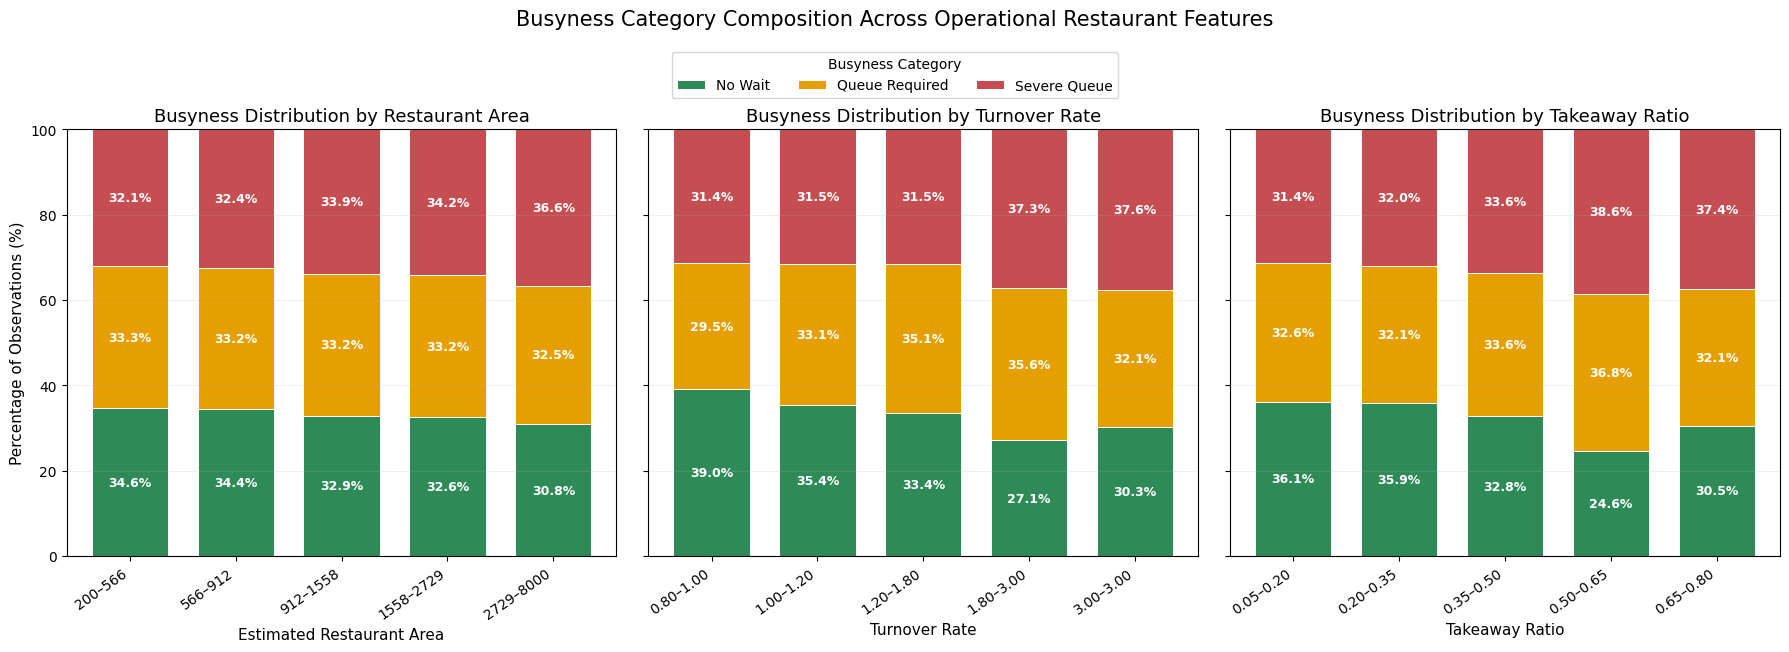

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Prepare data
# =========================================================
df_plot = df.copy()

busyness_order = [
    "No Wait",
    "Queue Required",
    "Severe Queue"
]

df_plot["busyness_category"] = pd.cut(
    df_plot["busyness_score"],
    bins=[-0.001, 0, 50, np.inf],
    labels=busyness_order,
    include_lowest=True,
    right=True
)


# =========================================================
# 2. Check column names
# =========================================================
required_columns = [
    "estimated_area_sqft",
    "turnover_rate",
    "takeaway_ratio",
    "busyness_score"
]

missing_columns = [
    col for col in required_columns
    if col not in df_plot.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns:\n{df_plot.columns.tolist()}"
    )


# =========================================================
# 3. Create five groups
# =========================================================
def create_ranked_quintiles(series):
    """
    Create five approximately equal-sized groups.

    Ranking avoids qcut dropping bins when many values
    are repeated.
    """
    numeric = pd.to_numeric(series, errors="coerce")
    result = pd.Series(index=series.index, dtype="object")

    valid = numeric.notna()

    ranks = numeric.loc[valid].rank(
        method="first",
        pct=True
    )

    result.loc[valid] = pd.cut(
        ranks,
        bins=np.linspace(0, 1, 6),
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
        include_lowest=True
    ).astype(str)

    return result


# Area and turnover rate:
# use quintiles because their distributions may be skewed
df_plot["area_bin"] = create_ranked_quintiles(
    df_plot["estimated_area_sqft"]
)

df_plot["turnover_bin"] = create_ranked_quintiles(
    df_plot["turnover_rate"]
)

# Takeaway ratio:
# use equal-width intervals because it has a meaningful ratio scale
df_plot["takeaway_bin"] = pd.cut(
    pd.to_numeric(df_plot["takeaway_ratio"], errors="coerce"),
    bins=5,
    include_lowest=True
)


# =========================================================
# 4. Calculate percentages within each group
# =========================================================
def calculate_busyness_percentages(data, bin_column):
    valid_data = data.dropna(
        subset=[bin_column, "busyness_category"]
    )

    table = pd.crosstab(
        valid_data[bin_column],
        valid_data["busyness_category"],
        normalize="index"
    ) * 100

    table = table.reindex(
        columns=busyness_order,
        fill_value=0
    )

    return table


area_pct = calculate_busyness_percentages(
    df_plot,
    "area_bin"
)

turnover_pct = calculate_busyness_percentages(
    df_plot,
    "turnover_bin"
)

takeaway_pct = calculate_busyness_percentages(
    df_plot,
    "takeaway_bin"
)


# =========================================================
# 5. Generate actual range labels for quintile groups
# =========================================================
def create_range_labels(
    data,
    feature_column,
    bin_column,
    group_order,
    decimals=1
):
    labels = []

    for group in group_order:
        values = pd.to_numeric(
            data.loc[
                data[bin_column] == group,
                feature_column
            ],
            errors="coerce"
        ).dropna()

        if values.empty:
            labels.append(str(group))
        else:
            labels.append(
                f"{values.min():.{decimals}f}–"
                f"{values.max():.{decimals}f}"
            )

    return labels


area_labels = create_range_labels(
    df_plot,
    feature_column="estimated_area_sqft",
    bin_column="area_bin",
    group_order=area_pct.index,
    decimals=0
)

turnover_labels = create_range_labels(
    df_plot,
    feature_column="turnover_rate",
    bin_column="turnover_bin",
    group_order=turnover_pct.index,
    decimals=2
)


def format_interval_labels(index, decimals=2):
    labels = []

    for interval in index:
        if isinstance(interval, pd.Interval):
            labels.append(
                f"{interval.left:.{decimals}f}–"
                f"{interval.right:.{decimals}f}"
            )
        else:
            labels.append(str(interval))

    return labels


takeaway_labels = format_interval_labels(
    takeaway_pct.index,
    decimals=2
)


# =========================================================
# 6. Plotting function
# =========================================================
category_colours = {
    "No Wait": "#2E8B57",
    "Queue Required": "#E69F00",
    "Severe Queue": "#C44E52"
}


def draw_100pct_stacked_bar(
    ax,
    table,
    x_labels,
    title,
    xlabel
):
    x = np.arange(len(table))
    bottom = np.zeros(len(table))

    for category in busyness_order:
        values = table[category].to_numpy()

        bars = ax.bar(
            x,
            values,
            bottom=bottom,
            width=0.72,
            label=category,
            color=category_colours[category],
            edgecolor="white",
            linewidth=0.7
        )

        for i, (bar, value) in enumerate(zip(bars, values)):
            if value >= 5:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[i] + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="white",
                    fontweight="bold"
                )

        bottom += values

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel, fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(
        x_labels,
        rotation=35,
        ha="right"
    )

    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.grid(axis="y", alpha=0.2)


# =========================================================
# 7. Draw the three charts
# =========================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    sharey=True
)

draw_100pct_stacked_bar(
    axes[0],
    area_pct,
    area_labels,
    "Busyness Distribution by Restaurant Area",
    "Estimated Restaurant Area"
)

draw_100pct_stacked_bar(
    axes[1],
    turnover_pct,
    turnover_labels,
    "Busyness Distribution by Turnover Rate",
    "Turnover Rate"
)

draw_100pct_stacked_bar(
    axes[2],
    takeaway_pct,
    takeaway_labels,
    "Busyness Distribution by Takeaway Ratio",
    "Takeaway Ratio"
)

axes[0].set_ylabel(
    "Percentage of Observations (%)",
    fontsize=11
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Busyness Category",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True
)

fig.suptitle(
    "Busyness Category Composition Across Operational Restaurant Features",
    fontsize=15,
    y=1.08
)

plt.tight_layout()
plt.show()

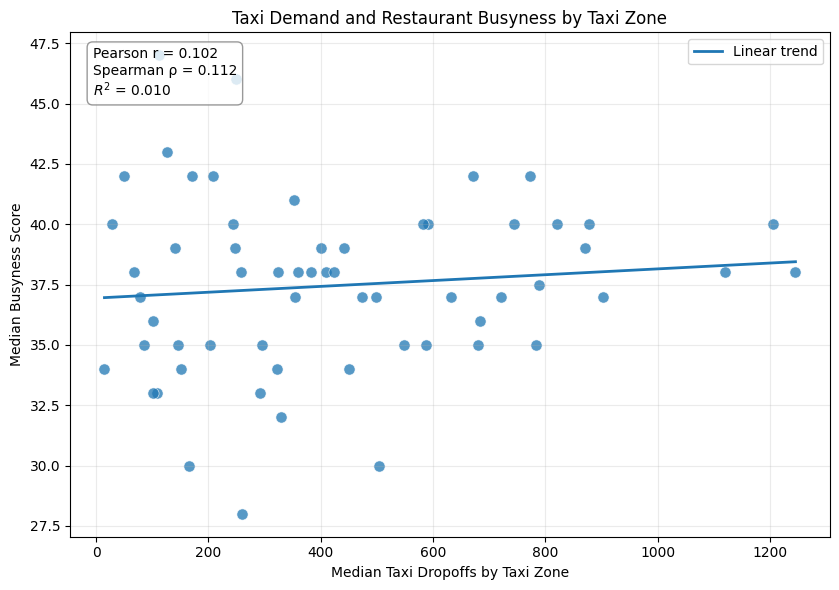

Number of Taxi Zones: 60
Slope: 0.001209
Pearson correlation: 0.102
Spearman correlation: 0.112
R-squared: 0.010


In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. Aggregate by Taxi Zone using median
# =====================================================
zone_df = (
    df.groupby("taxi_zone_id", as_index=False)
      .agg(
          median_dropoff=("dropoff_count", "median"),
          median_busyness=("busyness_score", "median"),
          restaurant_count=("restaurant_id", "nunique")
      )
)

# Remove missing and invalid observations
zone_df = (
    zone_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "median_dropoff",
            "median_busyness"
        ]
    )
    .copy()
)

zone_df = zone_df[
    zone_df["median_dropoff"] >= 0
].copy()


# =====================================================
# 2. Fit linear trend using original dropoff values
# =====================================================
slope, intercept = np.polyfit(
    zone_df["median_dropoff"],
    zone_df["median_busyness"],
    1
)

x_line = np.linspace(
    zone_df["median_dropoff"].min(),
    zone_df["median_dropoff"].max(),
    200
)

y_line = slope * x_line + intercept


# =====================================================
# 3. Calculate correlation and R-squared
# =====================================================
pearson_corr = zone_df[
    ["median_dropoff", "median_busyness"]
].corr(method="pearson").iloc[0, 1]

spearman_corr = zone_df[
    ["median_dropoff", "median_busyness"]
].corr(method="spearman").iloc[0, 1]

predicted_busyness = (
    slope * zone_df["median_dropoff"] + intercept
)

ss_residual = np.sum(
    (zone_df["median_busyness"] - predicted_busyness) ** 2
)

ss_total = np.sum(
    (
        zone_df["median_busyness"]
        - zone_df["median_busyness"].mean()
    ) ** 2
)

r_squared = (
    1 - ss_residual / ss_total
    if ss_total > 0
    else np.nan
)


# =====================================================
# 4. Plot
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 6))

ax.scatter(
    zone_df["median_dropoff"],
    zone_df["median_busyness"],
    s=65,
    alpha=0.75,
    edgecolors="white",
    linewidth=0.5
)

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Linear trend"
)

ax.set_xlabel("Median Taxi Dropoffs by Taxi Zone")
ax.set_ylabel("Median Busyness Score")

ax.set_title(
    "Taxi Demand and Restaurant Busyness by Taxi Zone"
)

ax.text(
    0.03,
    0.97,
    (
        f"Pearson r = {pearson_corr:.3f}\n"
        f"Spearman ρ = {spearman_corr:.3f}\n"
        f"$R^2$ = {r_squared:.3f}"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "alpha": 0.8,
        "edgecolor": "gray"
    }
)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


# =====================================================
# 5. Print results
# =====================================================
print(f"Number of Taxi Zones: {len(zone_df)}")
print(f"Slope: {slope:.6f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")